<a href="https://colab.research.google.com/github/A-ghori/sklearn/blob/recovery/Random_Simple_Imputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv("/content/Titanic-Dataset.csv", usecols=["Age","Fare","Survived"])
df.head(2)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833


In [57]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [58]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [59]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [61]:
X_train["Age_imputed"] = X_train["Age"]
X_test["Age_imputed"] = X_test["Age"]

In [62]:
X_test

,Age,Fare,Age_imputed
709,NaN,15.2458,NaN
439,31.0,10.5000,31.0
840,20.0,7.9250,20.0
720,6.0,33.0000,6.0
39,14.0,11.2417,14.0
...,...,...,...
433,17.0,7.1250,17.0
773,NaN,7.2250,NaN
25,38.0,31.3875,38.0
84,17.0,10.5000,17.0


## Now Implement the Random Simple Imputer on Age_Imputed for removing the missing values with the random number which are being selected from Age column itself

In [63]:
X_train["Age_imputed"][X_train["Age_imputed"].isnull()]

,Age_imputed
29,NaN
55,NaN
533,NaN
495,NaN
468,NaN
...,...
330,NaN
214,NaN
466,NaN
121,NaN


In [64]:
X_test["Age_imputed"][X_test["Age_imputed"].isnull()]

,Age_imputed
709,NaN
300,NaN
485,NaN
653,NaN
538,NaN
793,NaN
235,NaN
198,NaN
739,NaN
837,NaN


## Now Cover upper missing values
sample(X_train["Age"].isnull().sum()).values #Age ke non-missing values me se randomly utni values select karo jitne missing Age values hain, aur unhe NumPy array bana do.

In [65]:
print(X_train["Age"].isnull().sum())
print(X_train["Age_imputed"].isnull().sum())


print(X_test["Age"].isnull().sum())
print(X_test["Age_imputed"].isnull().sum())



140
140
37
37


In [66]:
X_train["Age_imputed"][X_train["Age_imputed"].isnull()] = X_train['Age'].dropna().sample(X_train["Age"].isnull().sum()).values

/tmp/ipykernel_1178/3194065085.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train["Age_imputed"][X_train["Age_imputed"].isnull()] = X_train['Age'].dropna().sample(X_train["Age"].isnull().sum()).values


In [67]:
X_test["Age_imputed"][X_test["Age_imputed"].isnull()] = X_test["Age"].dropna().sample(X_test["Age"].isnull().sum()).values

/tmp/ipykernel_1178/356259759.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_test["Age_imputed"][X_test["Age_imputed"].isnull()] = X_test["Age"].dropna().sample(X_test["Age"].isnull().sum()).values


In [68]:
#X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

In [69]:
X_test["Age_imputed"][X_test["Age_imputed"].isnull()]

,Age_imputed


/tmp/ipykernel_1178/1743179157.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age"], label="Original", hist=False)
/tmp/ipykernel_1178/1743179157.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age_imputed"], label="Imputed", hist=False)


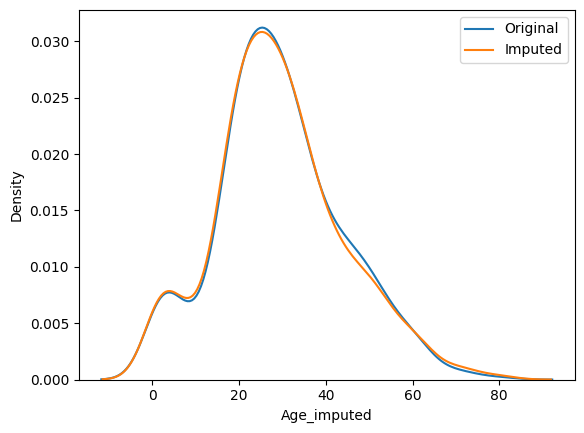

In [70]:
sns.distplot(X_train["Age"], label="Original", hist=False)
sns.distplot(X_train["Age_imputed"], label="Imputed", hist=False)

plt.legend()
plt.show()

In [71]:
print("Orginal Variable variance", X_train["Age"].var())
print("Imputed Variable variance", X_train["Age_imputed"].var())

Orginal Variable variance 210.2517072477438
Imputed Variable variance 218.61294852142888


In [72]:
X_train[["Age","Fare","Age_imputed"]].cov()

,Age,Fare,Age_imputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,49.677853
Age_imputed,210.251707,49.677853,218.612949


<Axes: >

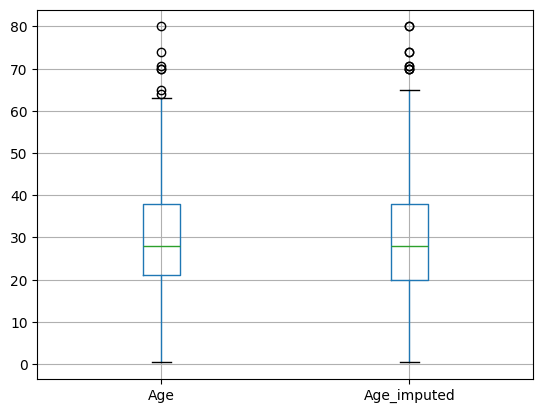

In [73]:
X_train[["Age", "Age_imputed"]].boxplot()

.sample(1, random_state=int(observation["Fare"]))

means:

Pick 1 random Age, using Fare to decide the random choice.

1 → pick one Age
random_state=... → make the random choice repeatable
observation["Fare"] → use that passenger's Fare as the random seed

So if:

observation["Fare"] = 50.75

then:

int(observation["Fare"])  # 50

and:

.sample(1, random_state=50)

👉 Pick one random Age using 50 as the seed.



Think of a seed like a starting number for randomness.

Normally:

.sample(1)

🎲 Random choice can be different every time.

But:

.sample(1, random_state=42)

🎲 Same starting point → same random choice every time.

So:

Seed = a number that controls the random selection.

Example:

random_state=42

means:
👉 "Start the randomness from 42, so I can reproduce the same result."

In [74]:
for index, observation in X_train.iterrows():
    if pd.isna(observation["Age"]):

      sample_valued = X_train["Age"].dropna().sample(
          1,
          random_state=int(observation["Fare"])
      )

      X_train.loc[index, "Age_imputed"] = sample_valued.iloc[0]
      #The loop checks every row; if Age is missing, it uses that row's Fare as a random seed to select one existing Age, then puts that selected Age into Age_imputed for that same row

## SIMPLE IMPUTER ON CATEGORICAL DATASET

In [77]:
data = pd.read_csv("/content/house-train.csv",usecols=["GarageQual", "FireplaceQu", "SalePrice"])
data.head(2)

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500


In [76]:
for column, datatype in data.dtypes.items():
  print(column,datatype)

Id int64
MSSubClass int64
MSZoning object
LotFrontage float64
LotArea int64
Street object
Alley object
LotShape object
LandContour object
Utilities object
LotConfig object
LandSlope object
Neighborhood object
Condition1 object
Condition2 object
BldgType object
HouseStyle object
OverallQual int64
OverallCond int64
YearBuilt int64
YearRemodAdd int64
RoofStyle object
RoofMatl object
Exterior1st object
Exterior2nd object
MasVnrType object
MasVnrArea float64
ExterQual object
ExterCond object
Foundation object
BsmtQual object
BsmtCond object
BsmtExposure object
BsmtFinType1 object
BsmtFinSF1 int64
BsmtFinType2 object
BsmtFinSF2 int64
BsmtUnfSF int64
TotalBsmtSF int64
Heating object
HeatingQC object
CentralAir object
Electrical object
1stFlrSF int64
2ndFlrSF int64
LowQualFinSF int64
GrLivArea int64
BsmtFullBath int64
BsmtHalfBath int64
FullBath int64
HalfBath int64
BedroomAbvGr int64
KitchenAbvGr int64
KitchenQual object
TotRmsAbvGrd int64
Functional object
Fireplaces int64
FireplaceQu object

In [79]:
data.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [80]:
X = data
y = data['SalePrice']

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [82]:
X_train['GarageQual_Imputed'] = X_train['GarageQual']
X_test['GarageQual_Imputed'] = X_test['GarageQual']

X_train['FireplaceQu_Imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_Imputed'] = X_test['FireplaceQu']


In [83]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_Imputed,FireplaceQu_Imputed
1203,TA,TA,213000,TA,TA
473,Ex,TA,440000,TA,Ex
1090,NaN,TA,92900,TA,NaN
388,NaN,TA,191000,TA,NaN
109,TA,TA,190000,TA,TA
